# Switching-Mess3 Belief-State Probe
## Training linear maps from transformer activations → 18-dim belief state

Follows the notation and equations in `switching_mess3_v2.pdf`.

**What this notebook does:**
1. Samples token sequences from the switching process (same generative model as training).
2. Computes the ground-truth 18-dim belief `ψ(t)` at every position using the exact Bayesian filter.
3. Extracts residual-stream activations from the transformer.
4. Fits a **Ridge regression** probe: activations → `ψ(t)`.
5. Extracts every derived quantity (λ, M¹, M², a¹, a², f²|¹, f¹|², μ¹, μ²) and evaluates direct probes for each.
6. Visualises predictions on the 2-simplex.

**Key equations (from the doc):**
- Within-block update:  `M¹ ← T₁(x)ᵀ M¹ / Z`,  `M² ← M² T₂(x) / Z`
- Switch boundary:  `M¹ ← (1-p)M¹ + p M²`,  `M² ← p M¹ + (1-p)M²`
- Active P1 belief:  `⟨a¹| = M¹·1 / λ`
- Marginal P1 belief: `⟨μ¹| = (M¹+M²)·1`


In [1]:
import json, os, warnings
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm

from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

# epsilon_transformers imports — adjust path if needed
from epsilon_transformers.persistence import Persister
from epsilon_transformers.process.processes import PROCESS_REGISTRY

warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)
print("Imports OK")


Imports OK


In [24]:
HOOK           = "blocks.0.hook_resid_pre"  # residual-stream hook to probe

In [3]:
# ── USER CONFIGURATION ──────────────────────────────────────────────────────
CHECKPOINT_DIR = "stage_p_0.9_25_mixed_ctx_100_l1_d_64_resume_4b_st_fixed"   # <-- set this


N_SEQUENCES    = 3000    # sequences to sample for probe training
SEQ_LEN        = 100      # length of each sequence
BATCH_SIZE     = 256     # inference batch size
RIDGE_ALPHA    = 1e-3    # Ridge regularisation
TEST_SIZE      = 0.2     # fraction held out for evaluation
# ────────────────────────────────────────────────────────────────────────────

device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else
    'cpu'
)
print(f"Device : {device}")


Device : cpu


In [4]:
config_path = Path(CHECKPOINT_DIR) / "train_config.json"
with open(config_path) as f:
    train_config = json.load(f)

mixing_params     = train_config["dataset"]["mixing_params"]
processes_config  = mixing_params["processes"]

if len(processes_config) != 2:
    raise ValueError("This notebook expects exactly 2 mixed processes.")

processes = []
for p_conf in processes_config:
    p_name   = p_conf[0]
    p_args   = p_conf[1]
    p_vocab  = ({int(k): v for k, v in p_conf[2].items()} if len(p_conf) > 2 else None)
    p = PROCESS_REGISTRY[p_name](vocab_map=p_vocab, **p_args)
    processes.append(p)

p0, p1 = processes
switch_times = mixing_params.get("switch_times", [])
switch_probs = mixing_params.get("switch_prob", [])
if isinstance(switch_probs, float):
    switch_probs = [switch_probs] * len(switch_times)

T0 = torch.tensor(p0.transition_matrix, dtype=torch.float32, device=device)
T1 = torch.tensor(p1.transition_matrix, dtype=torch.float32, device=device)

D_VOCAB    = T0.shape[0]
N0         = p0.num_states      # 3 for Mess3
N1         = p1.num_states      # 3 for Mess3
DIM_BELIEF = 2 * N0 * N1       # 18

persister = Persister(Path(CHECKPOINT_DIR))
model     = persister.load_final_model().to(device)
model.eval()

print(f"P0 : {p0.name}  (states={N0})")
print(f"P1 : {p1.name}  (states={N1})")
print(f"D_VOCAB    = {D_VOCAB}")
print(f"DIM_BELIEF = {DIM_BELIEF}")
print(f"d_model    = {model.cfg.d_model}")
print(f"Switch times : {switch_times}")
print(f"Switch probs : {switch_probs}")


[Persister] Found 1 checkpoints in stage_p_0.9_25_mixed_ctx_100_l1_d_64_resume_4b_st_fixed
[Persister] Found 1 checkpoints in stage_p_0.9_25_mixed_ctx_100_l1_d_64_resume_4b_st_fixed
Moving model to device:  cpu
P0 : mess3  (states=3)
P1 : mess3  (states=3)
D_VOCAB    = 3
DIM_BELIEF = 18
d_model    = 64
Switch times : [0, 4, 8, 12, 16, 20, 24, 28, 33, 37, 41, 45, 49, 53, 57, 61, 66, 70, 74, 78, 82, 86, 90, 94, 99]
Switch probs : [0.5, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9]


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
#  Core Bayesian filter for the switching Mess3 process
#  Notation follows switching_mess3_v2.pdf (Section 8)
#
#  Belief A has shape (2, N0, N1):
#    A[0] = M^(1)[s1, s2] = P(r=1, σ¹=s1, σ²=s2 | x_{1:t})
#    A[1] = M^(2)[s1, s2] = P(r=2, σ¹=s1, σ²=s2 | x_{1:t})
#
#  Flat 18-dim vector: psi = A.reshape(-1)
#    psi[0:9]  = M^(1) row-major  (indices 0–8)
#    psi[9:18] = M^(2) row-major  (indices 9–17)
# ─────────────────────────────────────────────────────────────────────────────

def get_switch_prob_at(t):
    """Returns switching probability at time step t."""
    if t in switch_times:
        return switch_probs[switch_times.index(t)]
    return 0.0


def make_initial_belief():
    """
    psi(0) = [1/2, 1/2] ⊗ π^(0) ⊗ π^(1)

    Returns A of shape (2, N0, N1).
    """
    pi0 = torch.tensor(p0.steady_state_vector, dtype=torch.float32, device=device)
    pi1 = torch.tensor(p1.steady_state_vector, dtype=torch.float32, device=device)
    outer = torch.outer(pi0, pi1)   # (N0, N1)
    A = torch.zeros(2, N0, N1, device=device)
    A[0] = 0.5 * outer
    A[1] = 0.5 * outer
    return A


def belief_step(A, token, sw_prob):
    """
    One step of the Bayesian filter (doc eq. 25–28).

    Within-block update:
      M^(1) ← T0[token]ᵀ · M^(1)   (T0 left-multiplies; updates s1 rows)
      M^(2) ← M^(2) · T1[token]     (T1 right-multiplies; updates s2 cols)

    Switch (applied first at step t if sw_prob > 0):
      M^(1) ← (1-p) M^(1) + p M^(2)
      M^(2) ← p M^(1) + (1-p) M^(2)

    Args:
        A       : (2, N0, N1) current belief
        token   : int, observed token index
        sw_prob : float in [0,1]

    Returns:
        A_next  : (2, N0, N1) updated, normalised belief
        Z       : float, predictive prob P(token | history)
    """
    # 1. Switch boundary (doc eq. 28)
    if sw_prob > 0.0:
        A_sw = torch.empty_like(A)
        A_sw[0] = (1.0 - sw_prob) * A[0] + sw_prob * A[1]
        A_sw[1] = sw_prob * A[0] + (1.0 - sw_prob) * A[1]
    else:
        A_sw = A

    # 2. Emission-conditioned transition (doc eqs. 25–26)
    T0_x = T0[token]                    # (N0, N0)
    T1_x = T1[token]                    # (N1, N1)
    unnorm_0 = A_sw[0] @ T0_x     # (N0, N1): regime 1 active, left-multiply
    unnorm_1 = T1_x.T()@ A_sw[1]          # (N0, N1): regime 2 active, right-multiply

    # 3. Global normaliser (doc eq. 5): Z = Z1 + Z2
    Z = unnorm_0.sum() + unnorm_1.sum()

    if Z.item() < 1e-15:
        return A, 0.0   # numerically degenerate – return unchanged

    A_next = torch.stack([unnorm_0, unnorm_1]) / Z

    return A_next, Z.item()


def compute_beliefs_for_sequence(sequence):
    """
    Run the full filter over a single token sequence.

    Returns:
        beliefs : np.ndarray (L, 18)  — psi(t) at each step t
        log_prob: float               — log P(sequence)
    """
    A       = make_initial_belief()
    beliefs  = []
    log_prob = 0.0

    for t, tok in enumerate(sequence):
        sw_prob      = get_switch_prob_at(t)
        A, Z         = belief_step(A, tok, sw_prob)
        beliefs.append(A.reshape(-1).cpu().numpy())
        if Z > 0:
            log_prob += np.log(Z)

    return np.stack(beliefs, axis=0), log_prob


print("Belief-update functions defined.")
print(f"Initial belief sum check: {make_initial_belief().sum().item():.4f}")


Belief-update functions defined.
Initial belief sum check: 1.0000


In [6]:
def sample_sequences(n, seq_len):
    """
    Draw n token sequences by ancestral sampling from the generative process.

    At each step:
      1. Apply switch dynamics to the current belief A.
      2. For every possible token x, compute the unnormalised belief updates:
           unnorm_0[x] = T0[x].T @ A_sw[0]   shape (N0, N1)   -- regime 1 active
           unnorm_1[x] = A_sw[1] @ T1[x]     shape (N0, N1)   -- regime 2 active
      3. Sum entries to get P(x), sample token.
      4. Commit belief with that token.

    T0 shape: (D_VOCAB, N0, N0)  -- T0[x, from_state, to_state]
    T1 shape: (D_VOCAB, N1, N1)
    A  shape: (2, N0, N1)
    """
    # T0.transpose(1,2) has shape (D_VOCAB, N0, N0)
    # where [x, j, i] = T0[x, i, j], i.e. the transpose of T0[x]
    T0t = T0.transpose(1, 2)  # (D_VOCAB, N0, N0): T0[x].T stacked

    sequences = np.zeros((n, seq_len), dtype=np.int64)
    beliefs   = np.zeros((n, seq_len, DIM_BELIEF), dtype=np.float32)

    for i in tqdm(range(n), desc="Sampling"):
        A = make_initial_belief()   # (2, N0, N1)

        for t in range(seq_len):
            sw_prob = get_switch_prob_at(t)

            # 1. Switch boundary
            if sw_prob > 0.0:
                A_sw = torch.empty_like(A)
                A_sw[0] = (1.0 - sw_prob) * A[0] + sw_prob * A[1]
                A_sw[1] = sw_prob * A[0] + (1.0 - sw_prob) * A[1]
            else:
                A_sw = A

            # 2. Compute unnorm updates for all tokens simultaneously
            #
            # unnorm_0[x] = T0[x].T @ A_sw[0]
            #   = einsum('xji, jk -> xik', T0, A_sw[0])  [using T0t = T0.transpose(1,2)]
            #   T0t: (D_VOCAB, N0, N0), A_sw[0]: (N0, N1)
            #   result: (D_VOCAB, N0, N1)
            unnorm_0 = torch.einsum('xij,jk->xik', T0t, A_sw[0])  # (D_VOCAB, N0, N1)

            # unnorm_1[x] = A_sw[1] @ T1[x]
            #   A_sw[1]: (N0, N1), T1: (D_VOCAB, N1, N1)
            #   result: (D_VOCAB, N0, N1)
            unnorm_1 = torch.einsum('ij,xjk->xik', A_sw[1], T1)   # (D_VOCAB, N0, N1)

            # 3. P(x) = sum of all entries of unnorm_0[x] + unnorm_1[x]
            px = unnorm_0.sum(dim=(1, 2)) + unnorm_1.sum(dim=(1, 2))  # (D_VOCAB,)
            px = px.clamp(min=0.0)
            px_sum = px.sum()
            if px_sum < 1e-15:
                px = torch.ones(D_VOCAB, device=device) / D_VOCAB
            else:
                px = px / px_sum

            tok = torch.multinomial(px, 1).item()
            sequences[i, t] = tok

            # 4. Commit: normalise belief for the sampled token
            un0 = unnorm_0[tok]   # (N0, N1)
            un1 = unnorm_1[tok]   # (N0, N1)
            Z   = un0.sum() + un1.sum()
            if Z < 1e-15:
                # degenerate — keep previous belief
                pass
            else:
                A = torch.stack([un0, un1]) / Z   # (2, N0, N1)

            beliefs[i, t] = A.reshape(-1).cpu().numpy()

    return sequences, beliefs


print(f"Sampling {N_SEQUENCES} sequences of length {SEQ_LEN} ...")
sequences_np, beliefs_np = sample_sequences(N_SEQUENCES, SEQ_LEN)

print(f"sequences_np : {sequences_np.shape}   dtype={sequences_np.dtype}")
print(f"beliefs_np   : {beliefs_np.shape}   dtype={beliefs_np.dtype}")
print(f"Belief sum   : {beliefs_np.sum(axis=-1).mean():.5f}  (should be ~1.0)")


Sampling 3000 sequences of length 100 ...


Sampling: 100%|██████████| 3000/3000 [01:40<00:00, 29.98it/s]

sequences_np : (3000, 100)   dtype=int64
beliefs_np   : (3000, 100, 18)   dtype=float32
Belief sum   : 1.00000  (should be ~1.0)


In [7]:
np.save(r'evaluation/sequences.npy', sequences_np)

In [8]:
np.save(r'evaluation/beliefs.npy', beliefs_np)

In [7]:
HOOK           = "blocks.0.hook_resid_mid"  # residual-stream hook to probe

In [25]:
def extract_activations(seqs_np, hook=HOOK, batch_size=BATCH_SIZE):
    """
    Run the transformer on all sequences, return residual-stream activations.

    Returns:
        acts : float32 ndarray  (N_sequences, seq_len, d_model)
    """
    N, L    = seqs_np.shape
    d_model = model.cfg.d_model
    acts    = np.zeros((N, L, d_model), dtype=np.float32)

    model.eval()
    with torch.no_grad():
        for i in tqdm(range(0, N, batch_size), desc="Activations"):
            batch = seqs_np[i : i + batch_size]
            x     = torch.tensor(batch, dtype=torch.long, device=device)
            _, cache = model.run_with_cache(
                x, names_filter=lambda name: name == hook
            )
            acts[i : i + len(batch)] = cache[hook].cpu().numpy()

    return acts


print(f"Extracting activations from hook: {HOOK}")
activations_np = extract_activations(sequences_np)
print(f"Activations : {activations_np.shape}")


Extracting activations from hook: blocks.0.hook_resid_pre


Activations: 100%|██████████| 12/12 [00:01<00:00,  6.15it/s]

Activations : (3000, 100, 64)


In [26]:
# Each (sequence, position) pair is one data point.
# Shapes: (N*L, d_model)  and  (N*L, 18)
acts_flat    = activations_np.reshape(-1, activations_np.shape[-1])   # (N*L, d_model)
beliefs_flat = beliefs_np.reshape(-1, beliefs_np.shape[-1])           # (N*L, 18)

# Also store a time-step index for each sample (useful for temporal analysis)
time_flat    = np.tile(np.arange(SEQ_LEN), N_SEQUENCES)               # (N*L,)

print(f"Flat activations : {acts_flat.shape}")
print(f"Flat beliefs     : {beliefs_flat.shape}")

X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
    acts_flat, beliefs_flat, time_flat,
    test_size=TEST_SIZE, random_state=42
)
print(f"Train: {X_train.shape}   Test: {X_test.shape}")


Flat activations : (300000, 64)
Flat beliefs     : (300000, 18)
Train: (240000, 64)   Test: (60000, 64)


  18-dim belief probe   ψ(t) = (M¹, M²)
  Train │  MSE 0.001211  │  R² 0.3287
  Test  │  MSE 0.001215  │  R² 0.3280

Per-dim R² — M^(1) (regime 1):
[[0.526 0.509 0.51 ]
 [0.51  0.526 0.512]
 [0.51  0.509 0.522]]
Per-dim R² — M^(2) (regime 2):
[[0.141 0.141 0.145]
 [0.141 0.14  0.141]
 [0.141 0.141 0.14 ]]


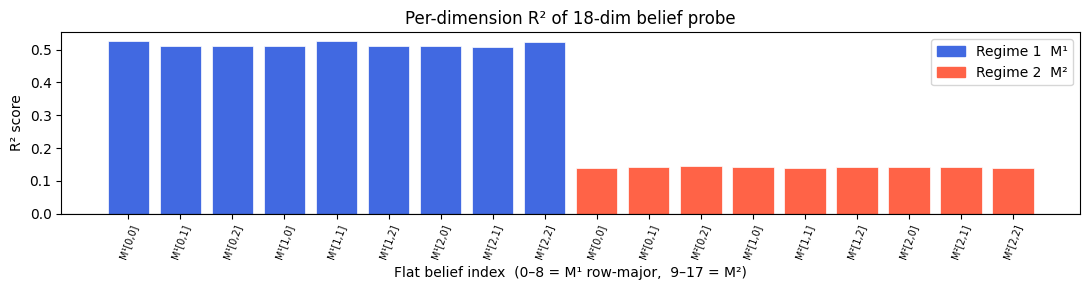

In [27]:
# ─────────────────────────────────────────────────────────────────────────────
#  Probe 0: activations → full 18-dim belief  ψ(t)
# ─────────────────────────────────────────────────────────────────────────────

probe_18 = Ridge(alpha=RIDGE_ALPHA)
probe_18.fit(X_train, y_train)

y_pred_train = probe_18.predict(X_train)
y_pred_test  = probe_18.predict(X_test)

mse_train_18 = mean_squared_error(y_train, y_pred_train)
mse_test_18  = mean_squared_error(y_test,  y_pred_test)
r2_train_18  = r2_score(y_train, y_pred_train)
r2_test_18   = r2_score(y_test,  y_pred_test)

print("=" * 52)
print("  18-dim belief probe   ψ(t) = (M¹, M²)")
print("=" * 52)
print(f"  Train │  MSE {mse_train_18:.6f}  │  R² {r2_train_18:.4f}")
print(f"  Test  │  MSE {mse_test_18:.6f}  │  R² {r2_test_18:.4f}")
print()

# Per-dimension R² — reshape to (2, N0, N1) for interpretation
r2_per_dim   = np.array([r2_score(y_test[:, d], y_pred_test[:, d])
                          for d in range(DIM_BELIEF)])
r2_matrix    = r2_per_dim.reshape(2, N0, N1)

print(f"Per-dim R² — M^(1) (regime 1):")
print(np.round(r2_matrix[0], 3))
print(f"Per-dim R² — M^(2) (regime 2):")
print(np.round(r2_matrix[1], 3))

# Plot
fig, ax = plt.subplots(figsize=(11, 3))
colors   = ['royalblue'] * (N0 * N1) + ['tomato'] * (N0 * N1)
ax.bar(range(DIM_BELIEF), r2_per_dim, color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel("Flat belief index  (0–8 = M¹ row-major,  9–17 = M²)")
ax.set_ylabel("R² score")
ax.set_title("Per-dimension R² of 18-dim belief probe")
ax.set_xticks(range(DIM_BELIEF))
ax.set_xticklabels(
    [f'M¹[{i//N1},{i%N1}]' for i in range(N0*N1)] +
    [f'M²[{i//N1},{i%N1}]' for i in range(N0*N1)],
    rotation=70, fontsize=7
)
ax.legend(handles=[
    mpatches.Patch(color='royalblue', label='Regime 1  M¹'),
    mpatches.Patch(color='tomato',    label='Regime 2  M²'),
])
plt.tight_layout()
plt.savefig("r2_per_dim.png", dpi=150, bbox_inches='tight')
plt.show()


In [28]:
# ─────────────────────────────────────────────────────────────────────────────
#  Extract every derived quantity from a flat 18-dim belief array
#  Follows doc Section 9 exactly
# ─────────────────────────────────────────────────────────────────────────────

def extract_marginals(psi_flat):
    """
    Args:
        psi_flat : np.ndarray (N, 18)

    Returns dict of arrays:
        'lambda' : (N,)       regime weight λ = P(r=1|x_{1:t})
        'M1'     : (N, N0, N1)
        'M2'     : (N, N0, N1)
        'a1'     : (N, N0)   active P1 belief  = M¹·1 / λ        (doc eq. 29)
        'f21'    : (N, N1)   frozen P2|r=1     = 1ᵀ·M¹ / λ       (doc eq. 30)
        'f12'    : (N, N0)   frozen P1|r=2     = M²·1 / (1-λ)    (doc eq. 31)
        'a2'     : (N, N1)   active P2 belief  = 1ᵀ·M² / (1-λ)  (doc eq. 32)
        'mu1'    : (N, N0)   marginal P1       = (M¹+M²)·1        (doc eq. 33)
        'mu2'    : (N, N1)   marginal P2       = 1ᵀ·(M¹+M²)      (doc eq. 34)
    """
    N    = len(psi_flat)
    M1   = psi_flat[:, :N0*N1].reshape(N, N0, N1)     # (N, N0, N1)
    M2   = psi_flat[:, N0*N1:].reshape(N, N0, N1)     # (N, N0, N1)

    lam     = M1.sum(axis=(1, 2))                       # (N,)
    one_lam = M2.sum(axis=(1, 2))                       # (N,)

    # safe denominators
    lam_s     = np.where(lam     > 1e-12, lam,     1.0)
    one_lam_s = np.where(one_lam > 1e-12, one_lam, 1.0)

    # Level 1 — regime-conditional
    a1  = M1.sum(axis=2) / lam_s[:, None]              # (N, N0)
    f21 = M1.sum(axis=1) / lam_s[:, None]              # (N, N1)
    f12 = M2.sum(axis=2) / one_lam_s[:, None]          # (N, N0)
    a2  = M2.sum(axis=1) / one_lam_s[:, None]          # (N, N1)

    # Level 2 — marginal
    Mt  = M1 + M2
    mu1 = Mt.sum(axis=2)                                # (N, N0)
    mu2 = Mt.sum(axis=1)                                # (N, N1)

    return dict(lam=lam, M1=M1, M2=M2,
                a1=a1, f21=f21, f12=f12, a2=a2,
                mu1=mu1, mu2=mu2)


# Ground-truth marginals
gt_train  = extract_marginals(y_train)
gt_test   = extract_marginals(y_test)

# Marginals derived from 18-dim probe predictions
from18_train = extract_marginals(y_pred_train)
from18_test  = extract_marginals(y_pred_test)

print("Ground-truth marginals extracted.")
for k, v in gt_test.items():
    if k not in ('M1', 'M2'):
        print(f"  {k:6s}  shape={v.shape}")


Ground-truth marginals extracted.
  lam     shape=(60000,)
  a1      shape=(60000, 3)
  f21     shape=(60000, 3)
  f12     shape=(60000, 3)
  a2      shape=(60000, 3)
  mu1     shape=(60000, 3)
  mu2     shape=(60000, 3)


In [29]:
# ─────────────────────────────────────────────────────────────────────────────
#  Train a direct Ridge probe for each derived quantity
#  and compare with extracting the same quantity from the 18-dim probe.
# ─────────────────────────────────────────────────────────────────────────────

def probe_and_report(X_tr, X_te, y_tr, y_te, name, alpha=RIDGE_ALPHA):
    """Fit Ridge probe, compute MSE and R², return probe and test predictions."""
    # Handle 1-D target
    squeeze = (y_tr.ndim == 1)
    if squeeze:
        y_tr = y_tr[:, None]; y_te = y_te[:, None]

    p = Ridge(alpha=alpha)
    p.fit(X_tr, y_tr)
    pred_tr = p.predict(X_tr)
    pred_te = p.predict(X_te)

    mse_tr = mean_squared_error(y_tr, pred_tr)
    mse_te = mean_squared_error(y_te, pred_te)
    r2_tr  = r2_score(y_tr, pred_tr)
    r2_te  = r2_score(y_te, pred_te)

    print(f"  {name:26s}│ Train R²={r2_tr:.4f} MSE={mse_tr:.6f} "
          f"│ Test  R²={r2_te:.4f} MSE={mse_te:.6f}")

    if squeeze:
        pred_te = pred_te.ravel()
    return p, pred_te, r2_te, mse_te


print("=" * 90)
print("  Direct probes for each derived quantity")
print("=" * 90)

probes   = {}
preds_d  = {}    # direct probe predictions on test set
results  = {}    # (r2_direct, mse_direct, r2_from18, mse_from18)

TARGETS = [
    ('lam', 'λ (regime weight)'),
    ('mu1', 'μ¹ (marginal P1)'),
    ('mu2', 'μ² (marginal P2)'),
    ('a1',  'a¹ (active P1 | r=1)'),
    ('a2',  'a² (active P2 | r=2)'),
    ('f21', 'f²|¹ (frozen P2 | r=1)'),
    ('f12', 'f¹|² (frozen P1 | r=2)'),
]

for key, label in TARGETS:
    probes[key], preds_d[key], r2_d, mse_d = probe_and_report(
        X_train, X_test, gt_train[key], gt_test[key], label
    )
    # Evaluate extraction from 18-dim probe
    from18_pred = from18_test[key]
    r2_18  = r2_score(gt_test[key], from18_pred)
    mse_18 = mean_squared_error(gt_test[key], from18_pred)
    results[key] = (r2_d, mse_d, r2_18, mse_18)


  Direct probes for each derived quantity
  λ (regime weight)         │ Train R²=0.0008 MSE=0.011102 │ Test  R²=0.0001 MSE=0.011149
  μ¹ (marginal P1)          │ Train R²=0.3769 MSE=0.014712 │ Test  R²=0.3750 MSE=0.014806
  μ² (marginal P2)          │ Train R²=0.4015 MSE=0.003303 │ Test  R²=0.4027 MSE=0.003307
  a¹ (active P1 | r=1)      │ Train R²=0.7941 MSE=0.008702 │ Test  R²=0.7939 MSE=0.008719
  a² (active P2 | r=2)      │ Train R²=0.7815 MSE=0.002404 │ Test  R²=0.7816 MSE=0.002400
  f²|¹ (frozen P2 | r=1)    │ Train R²=0.0004 MSE=0.008942 │ Test  R²=-0.0002 MSE=0.008941
  f¹|² (frozen P1 | r=2)    │ Train R²=0.0003 MSE=0.034530 │ Test  R²=-0.0001 MSE=0.034674


In [30]:
print()
print("═" * 92)
print(f"  {'Quantity':<26}│{'Direct probe':^30}│{'From 18-dim probe':^30}")
print(f"  {'':26}│{'R²':>12}  {'MSE':>14}│{'R²':>12}  {'MSE':>14}")
print("─" * 92)
for key, label in TARGETS:
    r2_d, mse_d, r2_18, mse_18 = results[key]
    print(f"  {label:<26}│{r2_d:>12.4f}  {mse_d:>14.8f}│{r2_18:>12.4f}  {mse_18:>14.8f}")
print("═" * 92)
print()
print("Interpretation:")
print("  If Direct-probe R² >> From-18 R², the transformer encodes this quantity")
print("  in a subspace that the 18-dim probe doesn't fully capture.")
print("  If From-18 ≈ Direct, the 18-dim belief is a sufficient summary.")



════════════════════════════════════════════════════════════════════════════════════════════
  Quantity                  │         Direct probe         │      From 18-dim probe       
                            │          R²             MSE│          R²             MSE
────────────────────────────────────────────────────────────────────────────────────────────
  λ (regime weight)         │      0.0001      0.01114948│      0.0001      0.01114948
  μ¹ (marginal P1)          │      0.3750      0.01480618│      0.3750      0.01480617
  μ² (marginal P2)          │      0.4027      0.00330741│      0.4027      0.00330742
  a¹ (active P1 | r=1)      │      0.7939      0.00871924│      0.7930      0.00875441
  a² (active P2 | r=2)      │      0.7816      0.00240038│      0.7813      0.00240329
  f²|¹ (frozen P2 | r=1)    │     -0.0002      0.00894116│     -0.0003      0.00894139
  f¹|² (frozen P1 | r=2)    │     -0.0001      0.03467352│     -0.0001      0.03467622
══════════════════════════

In [31]:
# ─────────────────────────────────────────────────────────────────────────────
#  Simplex projection utilities
# ─────────────────────────────────────────────────────────────────────────────

# Vertices of the equilateral triangle: A, B, C
V = np.array([[0.0, 0.0],
              [1.0, 0.0],
              [0.5, np.sqrt(3)/2]])

def project_simplex(beliefs_3d):
    """
    Barycentric projection of (N, 3) probability vectors into 2D.
    beliefs_3d[i] = (p_A, p_B, p_C) → point in equilateral triangle.
    """
    b = np.asarray(beliefs_3d)
    xy = b @ V           # (N, 2) = barycentric coords @ vertex positions
    return xy[:, 0], xy[:, 1]


def draw_triangle(ax, labels=('A', 'B', 'C'), lw=0.8):
    """Draw triangle boundary and label vertices."""
    tri = np.vstack([V, V[0]])
    ax.plot(tri[:, 0], tri[:, 1], 'k-', lw=lw)
    offsets = [(-0.07, -0.07), (0.04, -0.07), (0.0, 0.05)]
    for v, lbl, off in zip(V, labels, offsets):
        ax.text(v[0]+off[0], v[1]+off[1], lbl, fontsize=10, ha='center')
    ax.set_aspect('equal')
    ax.axis('off')


def scatter_simplex(ax, beliefs, color='steelblue', alpha=0.25, s=3, label=None):
    x, y = project_simplex(beliefs)
    ax.scatter(x, y, s=s, alpha=alpha, color=color, label=label, rasterized=True)

print("Simplex utilities ready.")


Simplex utilities ready.


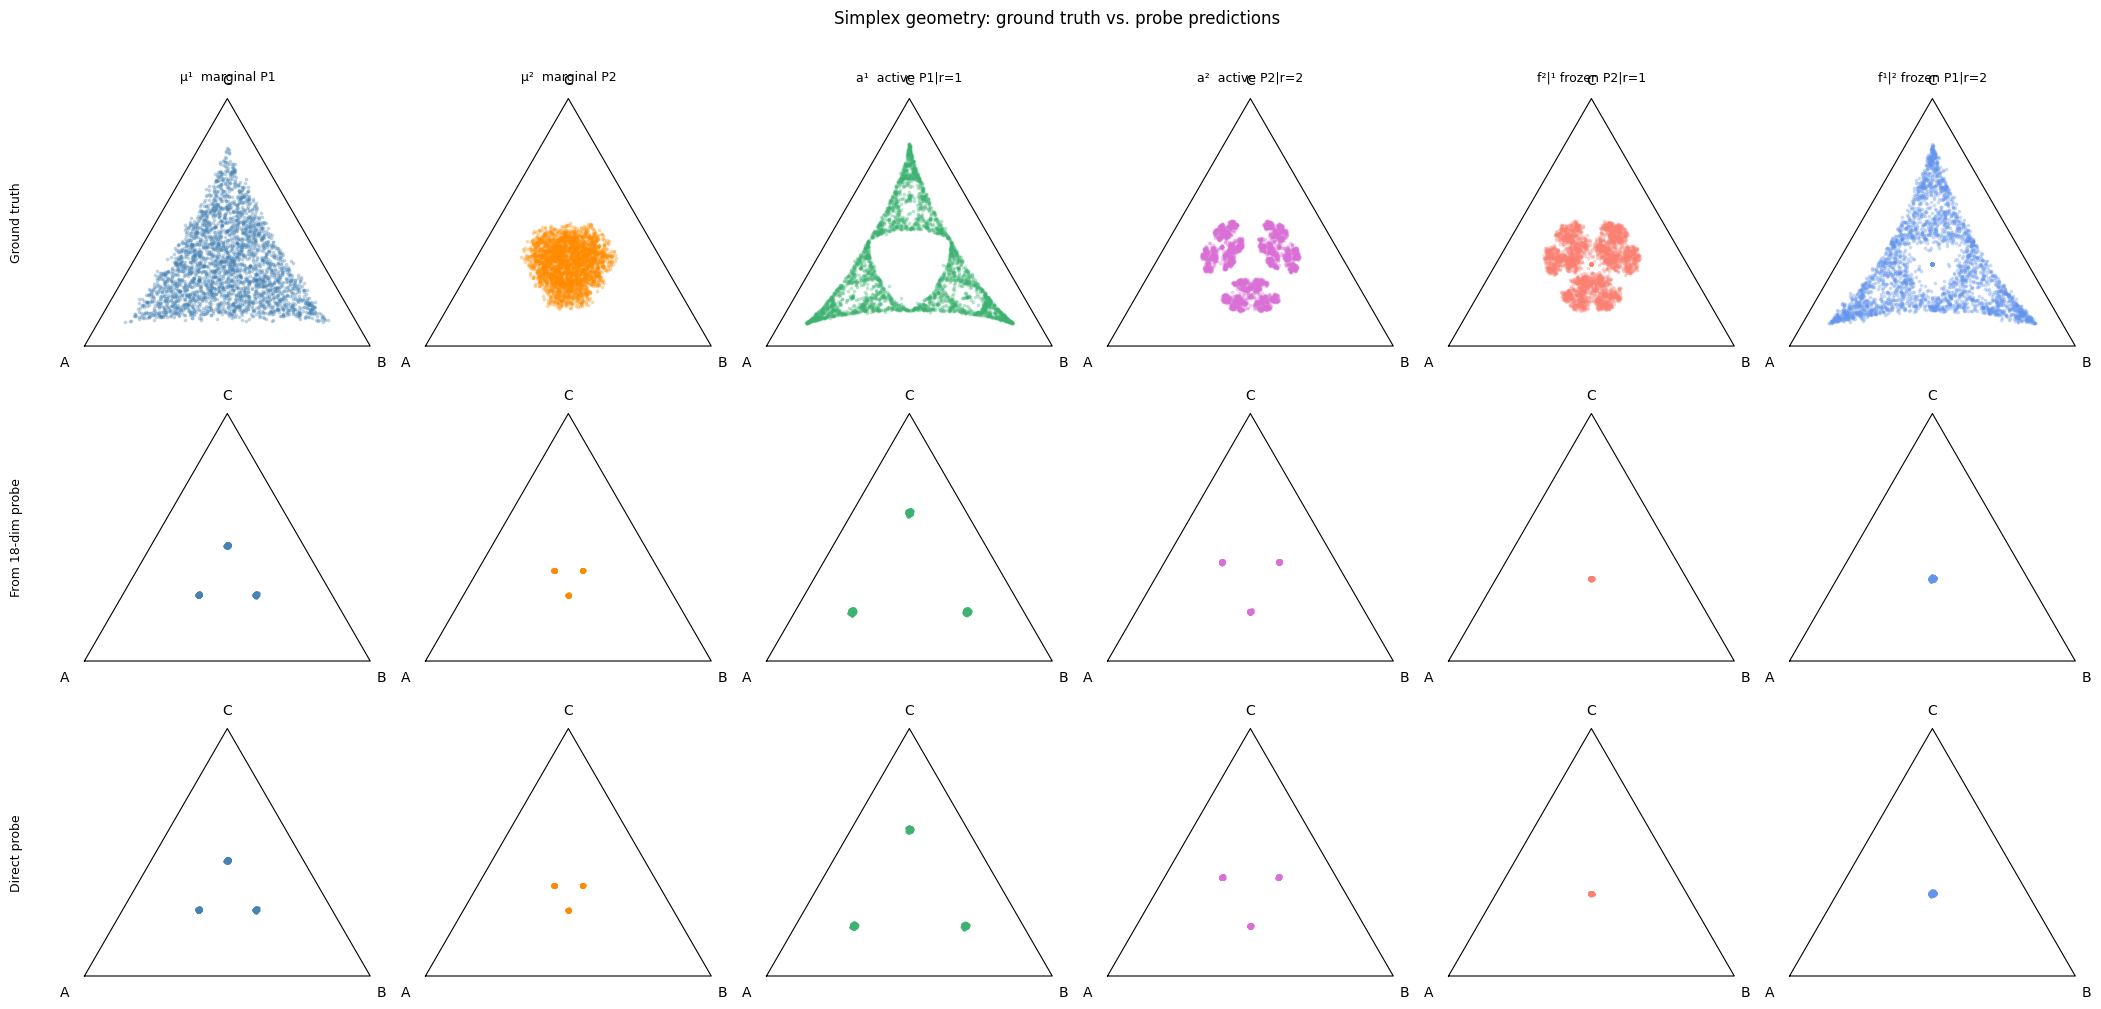

Note: a¹ and a² trace the EXACT single-process MSP fractal.
      μ¹ and μ² are blended versions (convex mixture of active + frozen).


In [32]:
# ─────────────────────────────────────────────────────────────────────────────
#  Figure 1: Ground truth vs. predictions for each marginal quantity
#  Rows: Ground truth | From 18-dim probe | Direct probe
#  Cols: μ¹  μ²  a¹  a²  f²|¹  f¹|²
# ─────────────────────────────────────────────────────────────────────────────

N_PLOT = min(3000, len(y_test))
idx    = np.random.choice(len(y_test), N_PLOT, replace=False)

COLS = [
    ('mu1', 'μ¹  marginal P1',   ('A','B','C'), 'steelblue'),
    ('mu2', 'μ²  marginal P2',   ('A','B','C'), 'darkorange'),
    ('a1',  'a¹  active P1|r=1', ('A','B','C'), 'mediumseagreen'),
    ('a2',  'a²  active P2|r=2', ('A','B','C'), 'orchid'),
    ('f21', 'f²|¹ frozen P2|r=1',('A','B','C'), 'salmon'),
    ('f12', 'f¹|² frozen P1|r=2',('A','B','C'), 'cornflowerblue'),
]

ROWS = ['Ground truth', 'From 18-dim probe', 'Direct probe']
fig, axes = plt.subplots(3, len(COLS), figsize=(3.5*len(COLS), 10))

for c, (key, title, lbls, col) in enumerate(COLS):
    gt_vals   = gt_test[key][idx]
    from18v   = from18_test[key][idx]
    direct_v  = np.clip(preds_d[key][idx] if preds_d[key].ndim > 1
                        else preds_d[key][idx, None], 0, None)
    if direct_v.ndim == 1: direct_v = direct_v[:, None]
    # renormalise direct prediction (not a valid simplex point otherwise)
    s = direct_v.sum(axis=1, keepdims=True)
    direct_v = direct_v / np.where(s < 1e-12, 1.0, s)

    for r, (vals, row_lbl) in enumerate([(gt_vals, ROWS[0]),
                                          (from18v,  ROWS[1]),
                                          (direct_v, ROWS[2])]):
        ax = axes[r, c]
        scatter_simplex(ax, vals, color=col)
        draw_triangle(ax, lbls)
        if r == 0:
            ax.set_title(title, fontsize=9, pad=4)
        if c == 0:
            ax.text(-0.15, 0.5, row_lbl, transform=ax.transAxes,
                    va='center', ha='right', fontsize=9, rotation=90)

plt.suptitle("Simplex geometry: ground truth vs. probe predictions", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("simplex_all.png", dpi=150, bbox_inches='tight')
plt.show()

print("Note: a¹ and a² trace the EXACT single-process MSP fractal.")
print("      μ¹ and μ² are blended versions (convex mixture of active + frozen).")


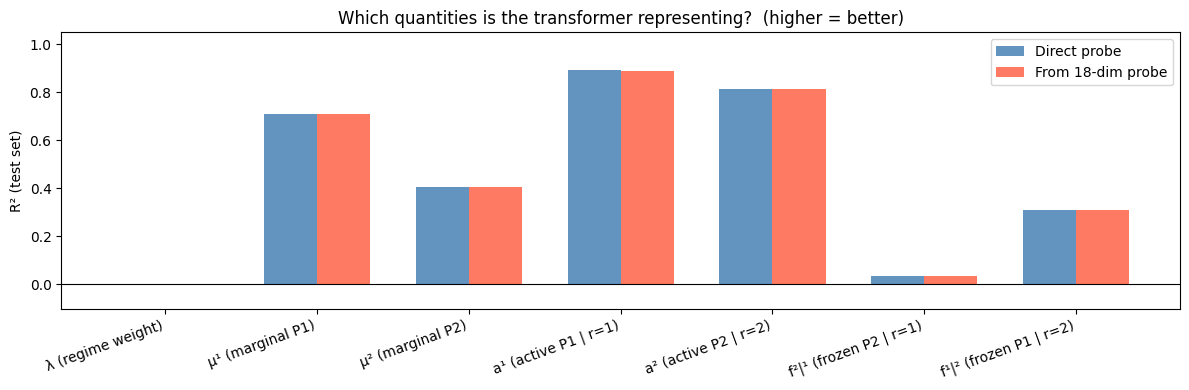

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
#  Figure 2: R² bar chart — which quantities does the model represent best?
# ─────────────────────────────────────────────────────────────────────────────

labels_bar  = [lbl for _, lbl in TARGETS]
r2_direct_v = [results[k][0] for k, _ in TARGETS]
r2_from18_v = [results[k][2] for k, _ in TARGETS]

x   = np.arange(len(TARGETS))
w   = 0.35
fig, ax = plt.subplots(figsize=(12, 4))
b1 = ax.bar(x - w/2, r2_direct_v, w, label='Direct probe',     color='steelblue', alpha=0.85)
b2 = ax.bar(x + w/2, r2_from18_v, w, label='From 18-dim probe', color='tomato',    alpha=0.85)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels_bar, rotation=20, ha='right', fontsize=10)
ax.set_ylabel("R² (test set)")
ax.set_title("Which quantities is the transformer representing?  (higher = better)")
ax.legend()
ax.set_ylim(-0.1, 1.05)
plt.tight_layout()
plt.savefig("r2_comparison.png", dpi=150, bbox_inches='tight')
plt.show()


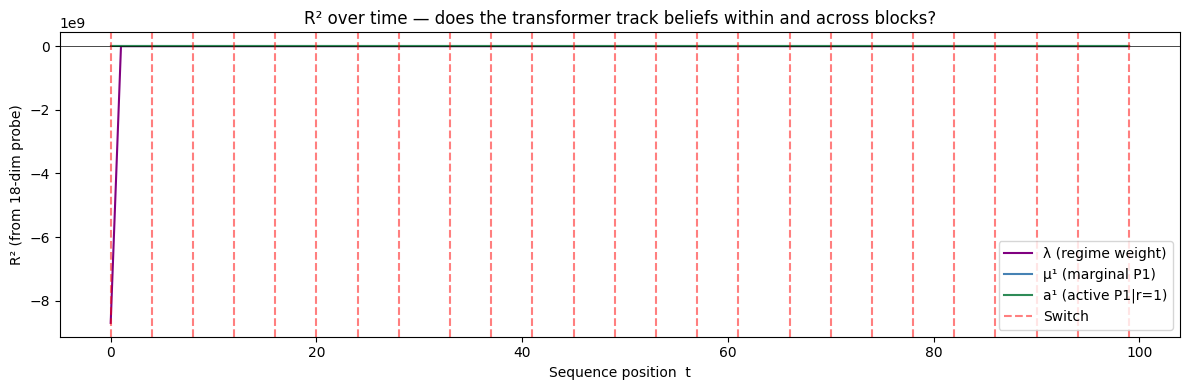

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
#  Figure 3: R² as a function of position within the sequence
#  — separates within-block inference from switch-boundary effects
# ─────────────────────────────────────────────────────────────────────────────

def r2_by_timestep(y_true_all, y_pred_all, t_idx_all, seq_len):
    r2s = []
    for t in range(seq_len):
        mask = (t_idx_all == t)
        if mask.sum() < 2:
            r2s.append(np.nan)
        else:
            r2s.append(r2_score(y_true_all[mask], y_pred_all[mask]))
    return np.array(r2s)

# Re-predict on the full (unshuffled) test set aligned with t_test
# Quantities to track over time
key_for_time = 'lam'   # regime weight is most interpretable

# Get per-step predictions from 18-dim probe for the test set
from18_test_all = extract_marginals(y_pred_test)

r2_lam_d18 = r2_by_timestep(gt_test['lam'], from18_test_all['lam'], t_test, SEQ_LEN)
r2_mu1_d18 = r2_by_timestep(gt_test['mu1'], from18_test_all['mu1'], t_test, SEQ_LEN)
r2_a1_d18  = r2_by_timestep(gt_test['a1'],  from18_test_all['a1'],  t_test, SEQ_LEN)

fig, ax = plt.subplots(figsize=(12, 4))
t_axis = np.arange(SEQ_LEN)
ax.plot(t_axis, r2_lam_d18, label='λ (regime weight)',     color='purple')
ax.plot(t_axis, r2_mu1_d18, label='μ¹ (marginal P1)',      color='steelblue')
ax.plot(t_axis, r2_a1_d18,  label='a¹ (active P1|r=1)',    color='seagreen')
ax.axhline(0, color='black', lw=0.5)
for st in switch_times:
    ax.axvline(st, color='red', linestyle='--', alpha=0.5, label='Switch' if st == switch_times[0] else '')
ax.set_xlabel("Sequence position  t")
ax.set_ylabel("R² (from 18-dim probe)")
ax.set_title("R² over time — does the transformer track beliefs within and across blocks?")
ax.legend()
plt.tight_layout()
plt.savefig("r2_over_time.png", dpi=150, bbox_inches='tight')
plt.show()



Can we recover the individual-process MSP simplexes?

From the 18-dim belief we can extract:

  a¹_t = M¹·1 / λ_t  — active P1 belief, given regime r=1
  a²_t = 1ᵀ·M² / (1−λ_t) — active P2 belief, given regime r=2

These quantities follow the EXACT single-process Riechers update within
each block:

  ⟨a¹_{t+1}| = ⟨a¹_t| T¹(x_{t+1}) / Z₁

and therefore a¹ lives on the single-process P1 MSP fractal, and a² on P2's.

The marginals μ¹ and μ² are convex mixtures:
  μ¹ = λ·a¹ + (1−λ)·f¹|²

They are blurred versions of the fractal — NOT the MSP itself.

Strategy to visualise the individual MSPs from the probe:
  1. Colour each point by λ_t (regime weight).
  2. Near λ_t ≈ 1: a¹ is well-determined; use those points only.
  3. Near λ_t ≈ 0: a² is well-determined.



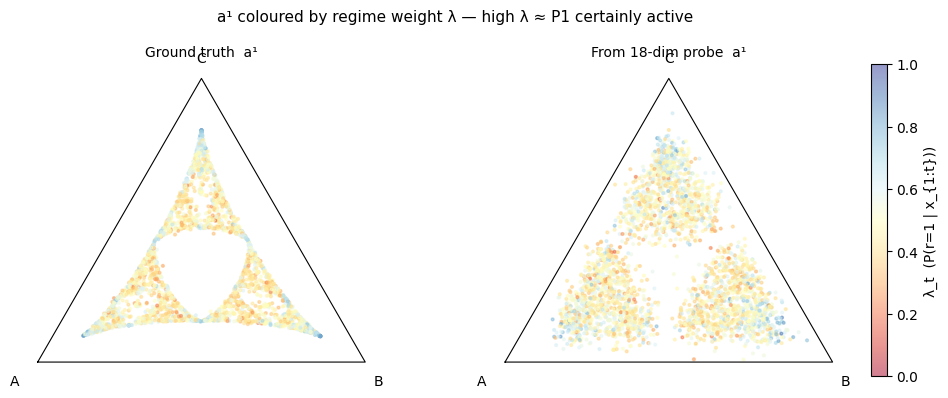

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
#  Can we recover the single-process MSP fractal geometry from the 18-dim probe?
# ─────────────────────────────────────────────────────────────────────────────

print("""
Can we recover the individual-process MSP simplexes?
====================================================

From the 18-dim belief we can extract:

  a¹_t = M¹·1 / λ_t  — active P1 belief, given regime r=1
  a²_t = 1ᵀ·M² / (1−λ_t) — active P2 belief, given regime r=2

These quantities follow the EXACT single-process Riechers update within
each block:

  ⟨a¹_{t+1}| = ⟨a¹_t| T¹(x_{t+1}) / Z₁

and therefore a¹ lives on the single-process P1 MSP fractal, and a² on P2's.

The marginals μ¹ and μ² are convex mixtures:
  μ¹ = λ·a¹ + (1−λ)·f¹|²

They are blurred versions of the fractal — NOT the MSP itself.

Strategy to visualise the individual MSPs from the probe:
  1. Colour each point by λ_t (regime weight).
  2. Near λ_t ≈ 1: a¹ is well-determined; use those points only.
  3. Near λ_t ≈ 0: a² is well-determined.
""")

# ── Colour-coded simplex: a¹ coloured by λ ───────────────────────────────────
lam_vals   = gt_test['lam'][idx]
a1_gt      = gt_test['a1'][idx]
a1_from18  = from18_test['a1'][idx]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, vals, title in [(axes[0], a1_gt,     'Ground truth  a¹'),
                         (axes[1], a1_from18, 'From 18-dim probe  a¹')]:
    x, y = project_simplex(vals)
    sc = ax.scatter(x, y, c=lam_vals, cmap='RdYlBu', s=4, alpha=0.5,
                    vmin=0, vmax=1, rasterized=True)
    draw_triangle(ax)
    ax.set_title(title, fontsize=10)
plt.colorbar(sc, ax=axes[1], label='λ_t  (P(r=1 | x_{1:t}))', fraction=0.04)
plt.suptitle("a¹ coloured by regime weight λ — high λ ≈ P1 certainly active", fontsize=11)
plt.tight_layout()
plt.savefig("a1_coloured_by_lambda.png", dpi=150, bbox_inches='tight')
plt.show()


P1 (use points where λ > thresh): 30 / 3000 points selected
P2 (use points where λ < 1-thresh): 18 / 3000 points selected


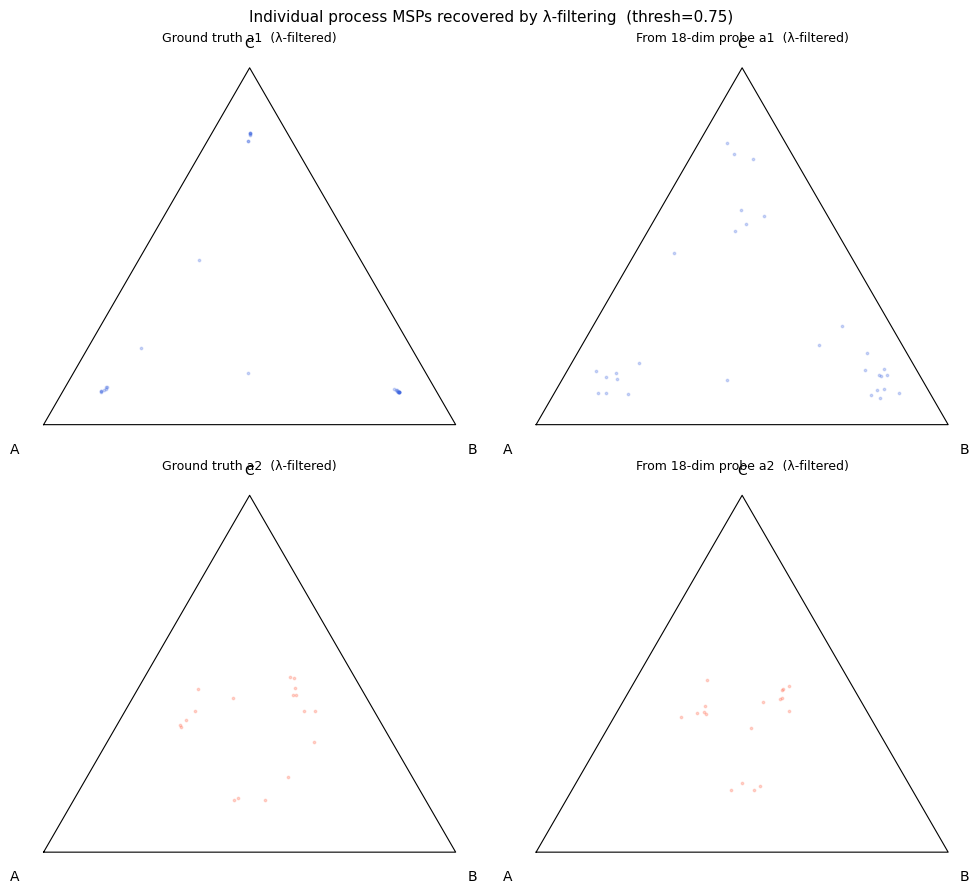

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
#  Figure: Filter by high λ to isolate the P1 MSP fractal
# ─────────────────────────────────────────────────────────────────────────────
LAMBDA_THRESH = 0.75   # only use points where we're reasonably sure of regime

fig, axes = plt.subplots(2, 2, figsize=(10, 9))

for ax_row, (regime_label, belief_key, lam_key, lam_dir) in enumerate([
    ('P1 (use points where λ > thresh)',  'a1', lam_vals,       True),
    ('P2 (use points where λ < 1-thresh)', 'a2', 1 - lam_vals, True),
]):
    mask = lam_dir * lam_vals > LAMBDA_THRESH if regime_label.startswith('P1')            else (1 - lam_vals) > LAMBDA_THRESH

    print(f"{regime_label}: {mask.sum()} / {len(mask)} points selected")

    gt_filt   = gt_test[belief_key][idx][mask]
    pred_filt = from18_test[belief_key][idx][mask]

    for ac, (vals, title) in enumerate([
        (gt_filt,   f'Ground truth {belief_key}  (λ-filtered)'),
        (pred_filt, f'From 18-dim probe {belief_key}  (λ-filtered)'),
    ]):
        ax = axes[ax_row, ac]
        scatter_simplex(ax, vals, color='royalblue' if ax_row == 0 else 'tomato')
        draw_triangle(ax)
        ax.set_title(title, fontsize=9)

plt.suptitle(f"Individual process MSPs recovered by λ-filtering  (thresh={LAMBDA_THRESH})",
             fontsize=11)
plt.tight_layout()
plt.savefig("msp_lambda_filtered.png", dpi=150, bbox_inches='tight')
plt.show()


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
#  Save probe coefficients and summary results
# ─────────────────────────────────────────────────────────────────────────────
import pickle

save_dir = Path(CHECKPOINT_DIR) 
save_dir.mkdir(exist_ok=True)

# Save all probes
with open(save_dir / "probes.pkl", "wb") as f:
    pickle.dump({'probe_18': probe_18, 'probes': probes}, f)

# Save numeric results
np.savez(
    save_dir / "probe_results.npz",
    # probe predictions on test set
    y_test              = y_test,
    y_pred_test_18      = y_pred_test,
    t_test              = t_test,
    # per-dim R²
    r2_per_dim_18       = r2_per_dim,
    # summary
    r2_test_18          = np.array([r2_test_18]),
    mse_test_18         = np.array([mse_test_18]),
)

# Save summary table as text
summary_lines = []
summary_lines.append(f"18-dim probe: R²={r2_test_18:.4f}  MSE={mse_test_18:.6f}")
for key, label in TARGETS:
    r2_d, mse_d, r2_18, mse_18 = results[key]
    summary_lines.append(
        f"{label:<26}: direct R²={r2_d:.4f} MSE={mse_d:.6f} | "
        f"from-18 R²={r2_18:.4f} MSE={mse_18:.6f}"
    )

with open(save_dir / "summary.txt", "w") as f:
    f.write("\n".join(summary_lines))

print("Saved to:", save_dir)
for line in summary_lines:
    print(" ", line)


UnicodeEncodeError: 'charmap' codec can't encode character '\u03bb' in position 39: character maps to <undefined>

Computing individual process beliefs...
Evaluating on 3 hooks...
Extracting activations for all hooks...
Processing hook: blocks.0.hook_resid_pre
Processing hook: blocks.0.hook_resid_mid
Processing hook: blocks.0.hook_resid_post


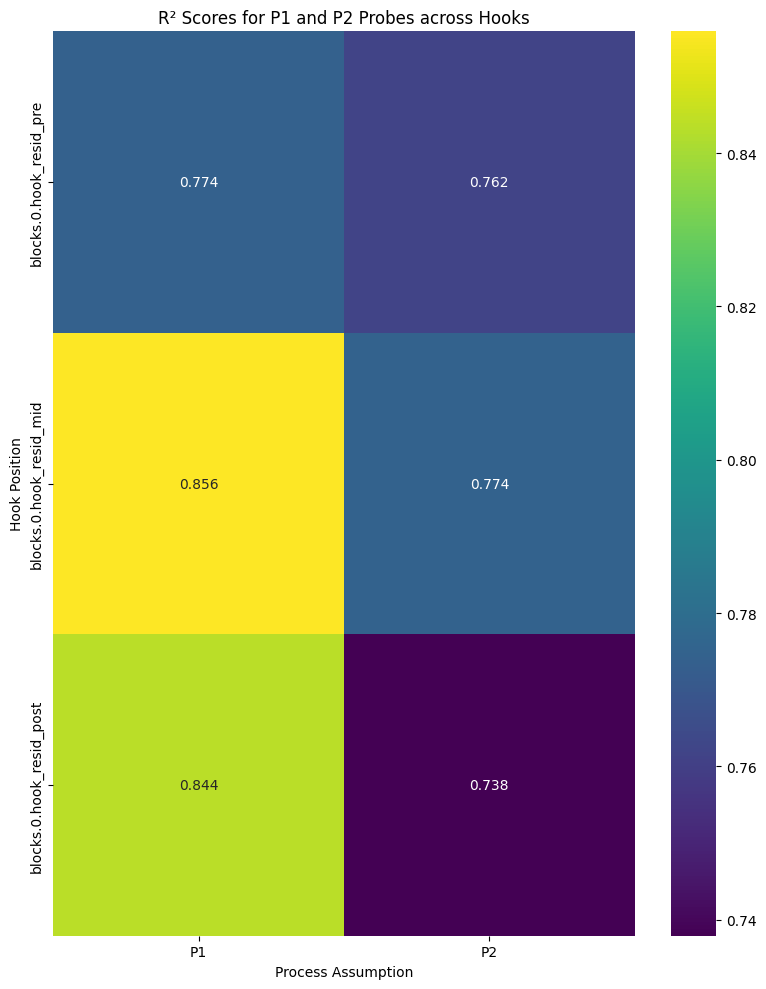

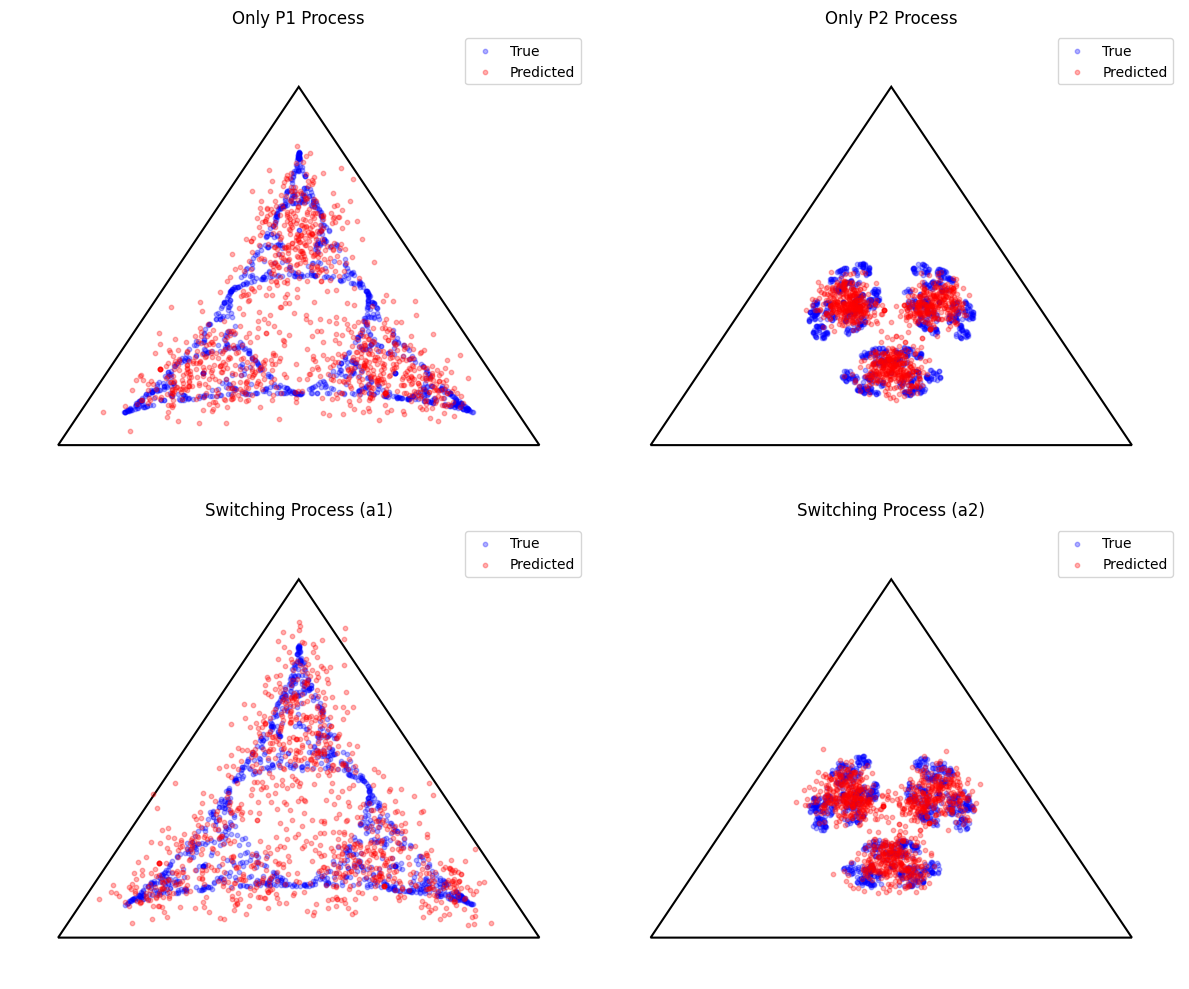

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
#  Train probes to recover 3-simplex for individual process (P1 or P2) without switching
#  Evaluate across all hook positions
# ─────────────────────────────────────────────────────────────────────────────
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from epsilon_transformers.analysis.simplex_analysis import SimplexAnalyzer
from epsilon_transformers.visualization.plots import _project_to_simplex

def extract_marginals_local(psi_flat, N0, N1):
    """Local copy of extract_marginals to ensure self-containment."""
    N = len(psi_flat)
    M1 = psi_flat[:, :N0*N1].reshape(N, N0, N1)
    M2 = psi_flat[:, N0*N1:].reshape(N, N0, N1)

    lam = M1.sum(axis=(1, 2))
    one_lam = M2.sum(axis=(1, 2))

    lam_s = np.where(lam > 1e-12, lam, 1.0)
    one_lam_s = np.where(one_lam > 1e-12, one_lam, 1.0)

    a1 = M1.sum(axis=2) / lam_s[:, None]
    a2 = M2.sum(axis=1) / one_lam_s[:, None]
    return {'a1': a1, 'a2': a2}

def train_and_evaluate_individual_process_probes(sequences_np, beliefs_np, p0, p1, model, checkpoint_dir):
    """
    Train linear probes to recover the 3-simplex assuming only P1 or only P2 generated the data.
    Does this for all residual stream hooks, saving weights and plotting R2/simplexes.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
    
    # 1. Compute Ground Truth beliefs for P1 and P2 without switching
    analyzer = SimplexAnalyzer(device=device)
    seqs_tensor = torch.tensor(sequences_np, dtype=torch.long, device=device)
    
    # Beliefs shape: [Batch, Seq_len, Num_states]
    print("Computing individual process beliefs...")
    beliefs_p1_tensor = analyzer._compute_beliefs_for_batch(seqs_tensor, p0)
    beliefs_p2_tensor = analyzer._compute_beliefs_for_batch(seqs_tensor, p1)
    
    # Flatten: [Batch * Seq_len, Num_states]
    beliefs_p1_flat = beliefs_p1_tensor.reshape(-1, p0.num_states).cpu().numpy()
    beliefs_p2_flat = beliefs_p2_tensor.reshape(-1, p1.num_states).cpu().numpy()
    
    N, L = sequences_np.shape
    d_model = model.cfg.d_model
    
    # Get the exact list of hooks requested
    hooks = ["blocks.0.hook_resid_pre"]
    for i in range(1):
        hooks.append(f"blocks.{i}.hook_resid_mid")
        hooks.append(f"blocks.{i}.hook_resid_post")
        
    # Store R2 scores: shape (num_hooks, 2) where 0 is P1, 1 is P2
    r2_scores = np.zeros((len(hooks), 2))
    
    # Output directory for probe weights
    out_dir = Path(checkpoint_dir) / "probe_weights"
    out_dir.mkdir(exist_ok=True, parents=True)
    
    # Pre-split indices to keep train/test sets consistent
    indices = np.arange(N * L)
    idx_train, idx_test = train_test_split(indices, test_size=TEST_SIZE, random_state=42)
    
    y_p1_train, y_p1_test = beliefs_p1_flat[idx_train], beliefs_p1_flat[idx_test]
    y_p2_train, y_p2_test = beliefs_p2_flat[idx_train], beliefs_p2_flat[idx_test]
    
    # Compute GT a1 and a2 for the switching process directly from beliefs_np
    beliefs_flat = beliefs_np.reshape(-1, beliefs_np.shape[-1])
    y_sw_train, y_sw_test = beliefs_flat[idx_train], beliefs_flat[idx_test]
    
    gt_test_local = extract_marginals_local(y_sw_test, p0.num_states, p1.num_states)
    
    print(f"Evaluating on {len(hooks)} hooks...")
    
    pred_p1_test_best = None
    pred_p2_test_best = None
    pred_a1_test_best = None
    pred_a2_test_best = None
    
    # Extract activations for all hooks in one pass
    print("Extracting activations for all hooks...")
    acts = {hook: np.zeros((N, L, d_model), dtype=np.float32) for hook in hooks}
    
    model.eval()
    with torch.no_grad():
        for i in range(0, N, BATCH_SIZE):
            batch = sequences_np[i : i + BATCH_SIZE]
            x = torch.tensor(batch, dtype=torch.long, device=device)
            _, cache = model.run_with_cache(x, names_filter=lambda name: name in hooks)
            for hook_name in hooks:
                acts[hook_name][i : i + len(batch)] = cache[hook_name].cpu().numpy()
    
    # Train 18-dim probe just for the best hook (the last one) to extract pred_a1 and pred_a2
    # We will do this at the end to save compute.
    
    # Iterate over hooks and train probes
    for h_idx, hook_name in enumerate(hooks):
        print(f"Processing hook: {hook_name}")
        acts_flat = acts[hook_name].reshape(-1, d_model)
        X_train, X_test = acts_flat[idx_train], acts_flat[idx_test]
        
        # Train P1 probe
        probe_p1 = Ridge(alpha=RIDGE_ALPHA)
        probe_p1.fit(X_train, y_p1_train)
        pred_p1_test = probe_p1.predict(X_test)
        r2_p1 = r2_score(y_p1_test, pred_p1_test)
        r2_scores[h_idx, 0] = r2_p1
        
        # Save P1 weights
        p1_weights_path = out_dir / f"{hook_name}_p1_weights.pt"
        torch.save(torch.tensor(probe_p1.coef_), p1_weights_path)
        
        # Train P2 probe
        probe_p2 = Ridge(alpha=RIDGE_ALPHA)
        probe_p2.fit(X_train, y_p2_train)
        pred_p2_test = probe_p2.predict(X_test)
        r2_p2 = r2_score(y_p2_test, pred_p2_test)
        r2_scores[h_idx, 1] = r2_p2
        
        # Save P2 weights
        p2_weights_path = out_dir / f"{hook_name}_p2_weights.pt"
        torch.save(torch.tensor(probe_p2.coef_), p2_weights_path)
        
        if h_idx == len(hooks) - 1: # save the last one for plotting
            pred_p1_test_best = pred_p1_test
            pred_p2_test_best = pred_p2_test
            
            # Train 18-dim switching probe on this hook to plot pred_a1, pred_a2
            probe_18 = Ridge(alpha=RIDGE_ALPHA)
            probe_18.fit(X_train, y_sw_train)
            pred_18_test = probe_18.predict(X_test)
            pred_marginals = extract_marginals_local(pred_18_test, p0.num_states, p1.num_states)
            pred_a1_test_best = pred_marginals['a1']
            pred_a2_test_best = pred_marginals['a2']

    # --- Plotting Heatmap ---
    plt.figure(figsize=(8, 10))
    sns.heatmap(r2_scores, annot=True, fmt=".3f", cmap="viridis",
                xticklabels=["P1", "P2"], yticklabels=hooks)
    plt.title("R² Scores for P1 and P2 Probes across Hooks")
    plt.ylabel("Hook Position")
    plt.xlabel("Process Assumption")
    plt.tight_layout()
    plt.savefig(out_dir / "r2_heatmap.png", dpi=150)
    plt.show()
    
    # --- Plotting Simplexes ---
    # We only plot a subset of 1000 points for clarity
    plot_idx = np.random.choice(len(y_p1_test), size=1000, replace=False)
    
    # Project to simplex (P1)
    true_x_p1, true_y_p1 = _project_to_simplex(y_p1_test[plot_idx])
    pred_x_p1, pred_y_p1 = _project_to_simplex(pred_p1_test_best[plot_idx])
    
    # Project to simplex (P2)
    true_x_p2, true_y_p2 = _project_to_simplex(y_p2_test[plot_idx])
    pred_x_p2, pred_y_p2 = _project_to_simplex(pred_p2_test_best[plot_idx])
    
    # Project to simplex (Switching a1 and a2)
    true_x_sw_a1, true_y_sw_a1 = _project_to_simplex(gt_test_local['a1'][plot_idx])
    true_x_sw_a2, true_y_sw_a2 = _project_to_simplex(gt_test_local['a2'][plot_idx])
    
    pred_x_sw_a1, pred_y_sw_a1 = _project_to_simplex(pred_a1_test_best[plot_idx])
    pred_x_sw_a2, pred_y_sw_a2 = _project_to_simplex(pred_a2_test_best[plot_idx])
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    def plot_simplex_panel(ax, true_x, true_y, pred_x, pred_y, title):
        # Draw outline of simplex
        simplex_corners = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2]])
        polygon = plt.Polygon(simplex_corners, fill=False, edgecolor='black', linewidth=1.5)
        ax.add_patch(polygon)
        ax.scatter(true_x, true_y, color='blue', alpha=0.3, s=10, label='True')
        if pred_x is not None:
            ax.scatter(pred_x, pred_y, color='red', alpha=0.3, s=10, label='Predicted')
        ax.set_title(title)
        ax.legend()
        ax.set_xlim(-0.1, 1.1)
        ax.set_ylim(-0.1, 1.0)
        ax.axis('off')
        
    plot_simplex_panel(axes[0], true_x_p1, true_y_p1, pred_x_p1, pred_y_p1, "Only P1 Process")
    plot_simplex_panel(axes[1], true_x_p2, true_y_p2, pred_x_p2, pred_y_p2, "Only P2 Process")
    plot_simplex_panel(axes[2], true_x_sw_a1, true_y_sw_a1, pred_x_sw_a1, pred_y_sw_a1, "Switching Process (a1)")
    plot_simplex_panel(axes[3], true_x_sw_a2, true_y_sw_a2, pred_x_sw_a2, pred_y_sw_a2, "Switching Process (a2)")
    
    plt.tight_layout()
    plt.savefig(out_dir / "simplex_recovery.png", dpi=150)
    plt.show()

# Run the function
train_and_evaluate_individual_process_probes(sequences_np, beliefs_np, p0, p1, model, CHECKPOINT_DIR)


# ─────────────────────────────────────────────────────────────────────────────
#  OV Circuit Subspace Analysis
#  Identify which attention heads update which process.
#  Computes norm(C_pre @ W_OV @ C_mid.T)
# ─────────────────────────────────────────────────────────────────────────────

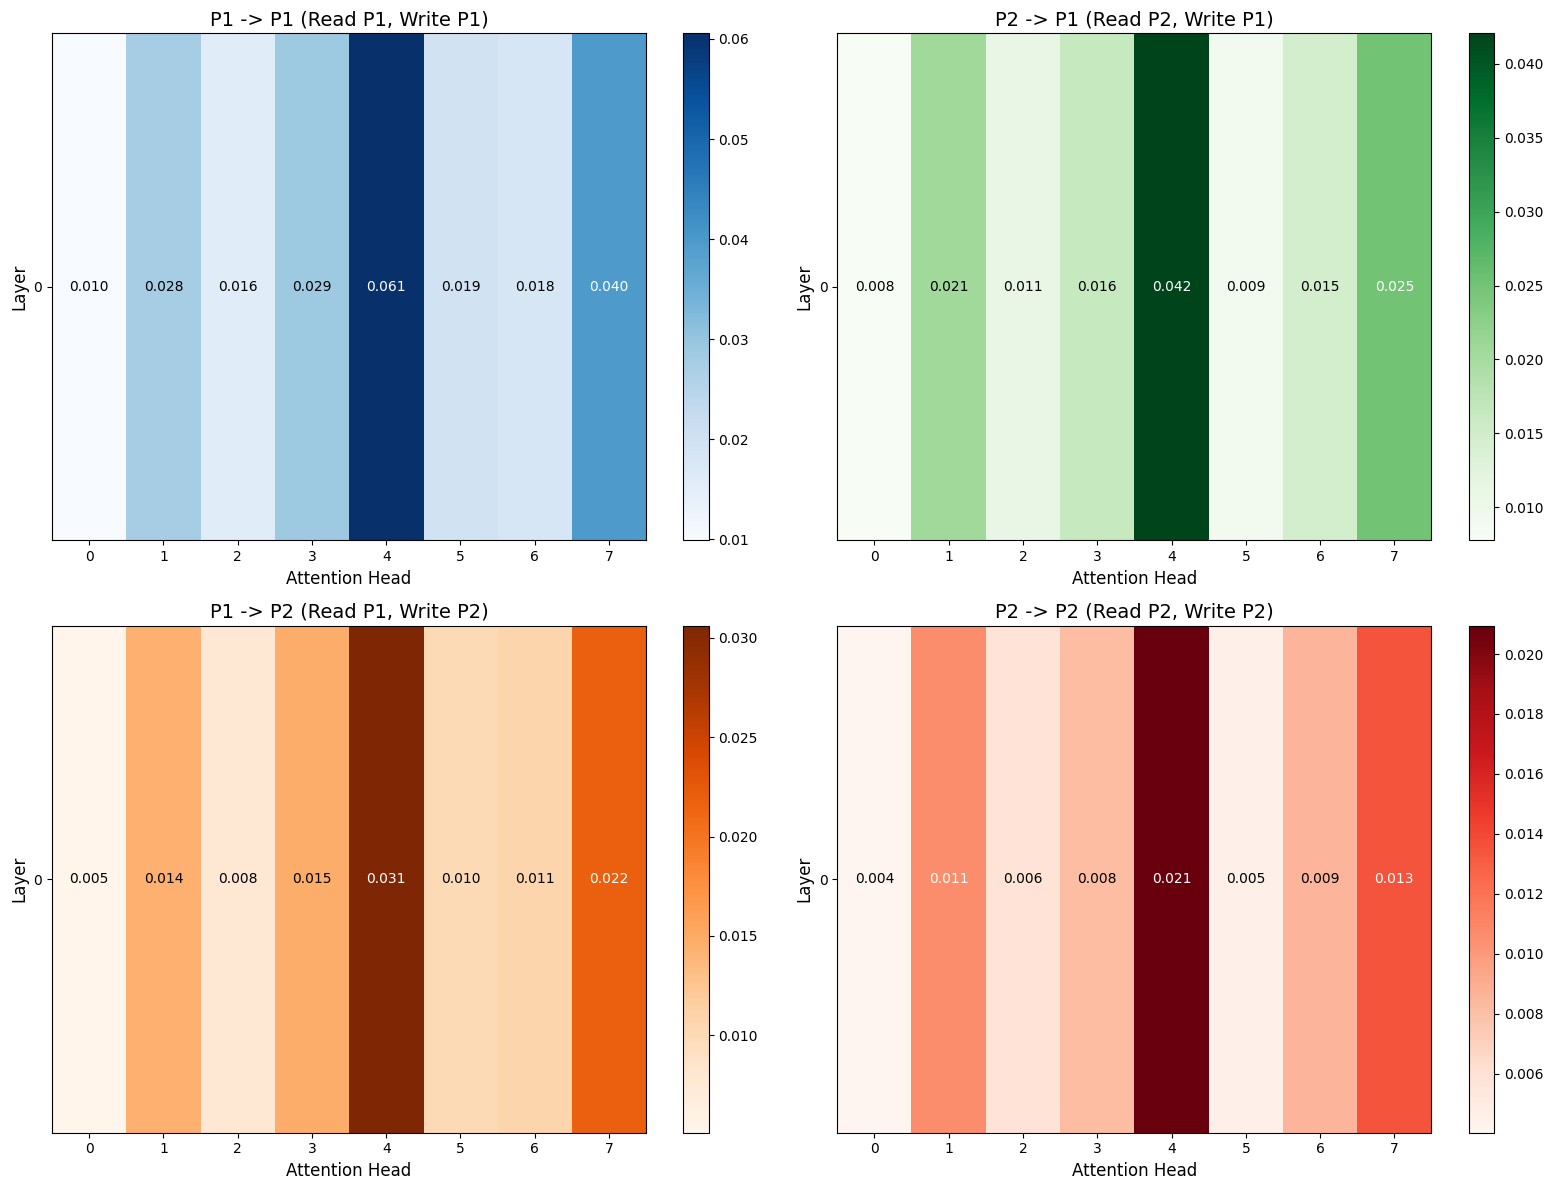

OV Subspace Analysis Complete. Plots saved to stage_p_0.9_25_mixed_ctx_100_l1_d_64_resume_4b_st_fixed\evaluation\ov_subspace_norms.png


In [21]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Extract model parameters
n_layers = model.cfg.n_layers
n_heads = model.cfg.n_heads
d_model = model.cfg.d_model
W_V = model.W_V  # (n_layers, n_heads, d_model, d_head)
W_O = model.W_O  # (n_layers, n_heads, d_head, d_model)
W_OV = W_V @ W_O # (n_layers, n_heads, d_model, d_model)

# Heatmaps for norms
norms_P1_P1 = np.zeros((n_layers, n_heads))
norms_P2_P1 = np.zeros((n_layers, n_heads))
norms_P1_P2 = np.zeros((n_layers, n_heads))
norms_P2_P2 = np.zeros((n_layers, n_heads))

probe_dir = Path(CHECKPOINT_DIR) / "probe_weights"

for l in range(n_layers):
    # Determine the "read" layer (pre)
    if l == 0:
        c_pre_p1 = torch.load(probe_dir / "blocks.0.hook_resid_pre_p1_weights.pt", map_location='cpu', weights_only=True)
        c_pre_p2 = torch.load(probe_dir / "blocks.0.hook_resid_pre_p2_weights.pt", map_location='cpu', weights_only=True)
    else:
        c_pre_p1 = torch.load(probe_dir / f"blocks.{l-1}.hook_resid_post_p1_weights.pt", map_location='cpu', weights_only=True)
        c_pre_p2 = torch.load(probe_dir / f"blocks.{l-1}.hook_resid_post_p2_weights.pt", map_location='cpu', weights_only=True)
    
    # Determine the "write" layer (mid)
    c_mid_p1 = torch.load(probe_dir / f"blocks.{l}.hook_resid_mid_p1_weights.pt", map_location='cpu', weights_only=True)
    c_mid_p2 = torch.load(probe_dir / f"blocks.{l}.hook_resid_mid_p2_weights.pt", map_location='cpu', weights_only=True)
    
    for h in range(n_heads):
        # Compute norms
        w_ov = W_OV[l, h].cpu()
        
        norms_P1_P1[l, h] = torch.norm(c_mid_p1 @ w_ov @ c_pre_p1.T, p='fro').item()
        norms_P2_P1[l, h] = torch.norm(c_mid_p2 @ w_ov @ c_pre_p1.T, p='fro').item()
        norms_P1_P2[l, h] = torch.norm(c_mid_p1 @ w_ov @ c_pre_p2.T, p='fro').item()
        norms_P2_P2[l, h] = torch.norm(c_mid_p2 @ w_ov @ c_pre_p2.T, p='fro').item()

# Create Evaluation Directory if it doesn't exist
eval_dir = Path(CHECKPOINT_DIR) / "evaluation"
eval_dir.mkdir(parents=True, exist_ok=True)

# Plotting Heatmaps
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
axs = axs.flatten()

heatmaps = [
    (norms_P1_P1, "P1 -> P1 (Read P1, Write P1)", 'Blues'),
    (norms_P2_P1, "P2 -> P1 (Read P2, Write P1)", 'Greens'),
    (norms_P1_P2, "P1 -> P2 (Read P1, Write P2)", 'Oranges'),
    (norms_P2_P2, "P2 -> P2 (Read P2, Write P2)", 'Reds')
]

for i, (data, title, cmap) in enumerate(heatmaps):
    im = axs[i].imshow(data, cmap=cmap, aspect='auto', origin='upper')
    fig.colorbar(im, ax=axs[i])
    # Add text annotations
    for y in range(data.shape[0]):
        for x in range(data.shape[1]):
            val = data[y, x]
            color = 'white' if val > data.max() / 2 else 'black'
            axs[i].text(x, y, f"{val:.3f}", ha="center", va="center", color=color)
    
    axs[i].set_title(title, fontsize=14)
    axs[i].set_xlabel("Attention Head", fontsize=12)
    axs[i].set_ylabel("Layer", fontsize=12)
    axs[i].set_xticks(np.arange(n_heads))
    axs[i].set_yticks(np.arange(n_layers))

plt.tight_layout()
plt.savefig(eval_dir / "ov_subspace_norms.png", dpi=150)
plt.show()

print("OV Subspace Analysis Complete. Plots saved to", eval_dir / "ov_subspace_norms.png")


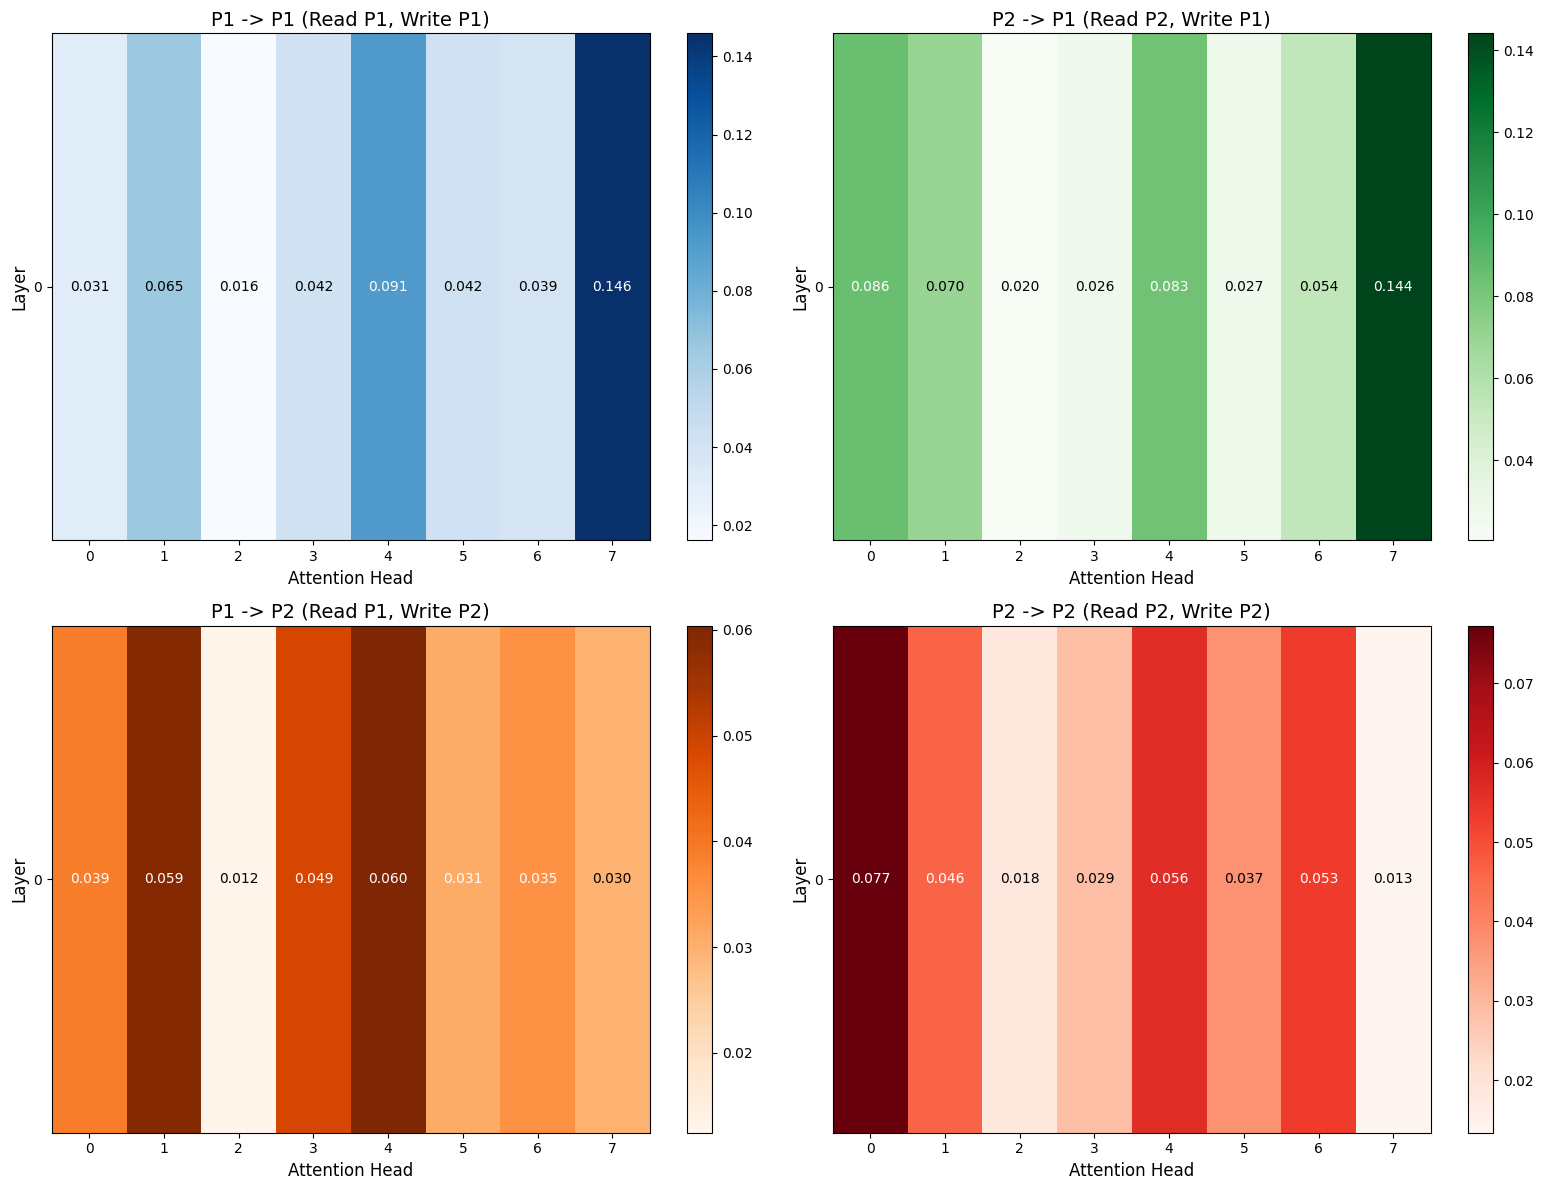

OV Subspace Analysis Complete. Plots saved to stage_p_0.9_25_mixed_ctx_100_l1_d_64_resume_4b_st_fixed\evaluation\ov_subspace_norms.png


In [22]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Extract model parameters
n_layers = model.cfg.n_layers
n_heads = model.cfg.n_heads
d_model = model.cfg.d_model
W_V = model.W_V  # (n_layers, n_heads, d_model, d_head)
W_O = model.W_O  # (n_layers, n_heads, d_head, d_model)
W_OV = W_V @ W_O # (n_layers, n_heads, d_model, d_model)

# Heatmaps for norms
norms_P1_P1 = np.zeros((n_layers, n_heads))
norms_P2_P1 = np.zeros((n_layers, n_heads))
norms_P1_P2 = np.zeros((n_layers, n_heads))
norms_P2_P2 = np.zeros((n_layers, n_heads))

probe_dir = Path(CHECKPOINT_DIR) / "probe_weights"

def get_orthonormal_basis(C):
    # C has shape (3, 64)
    # SVD: C = U @ S @ Vh, so Vh has shape (3, 64) and its rows are an orthonormal basis for the row space of C
    _, _, Vh = torch.linalg.svd(C, full_matrices=False)
    return Vh

for l in range(n_layers):
    # Determine the "read" layer (pre)
    if l == 0:
        c_pre_p1 = torch.load(probe_dir / "blocks.0.hook_resid_pre_p1_weights.pt", map_location='cpu', weights_only=True)
        c_pre_p2 = torch.load(probe_dir / "blocks.0.hook_resid_pre_p2_weights.pt", map_location='cpu', weights_only=True)
    else:
        c_pre_p1 = torch.load(probe_dir / f"blocks.{l-1}.hook_resid_post_p1_weights.pt", map_location='cpu', weights_only=True)
        c_pre_p2 = torch.load(probe_dir / f"blocks.{l-1}.hook_resid_post_p2_weights.pt", map_location='cpu', weights_only=True)
    
    # Determine the "write" layer (mid)
    c_mid_p1 = torch.load(probe_dir / f"blocks.{l}.hook_resid_mid_p1_weights.pt", map_location='cpu', weights_only=True)
    c_mid_p2 = torch.load(probe_dir / f"blocks.{l}.hook_resid_mid_p2_weights.pt", map_location='cpu', weights_only=True)
    
    # Extract scale-independent orthonormal bases for the subspaces
    vh_pre_p1 = get_orthonormal_basis(c_pre_p1)
    vh_pre_p2 = get_orthonormal_basis(c_pre_p2)
    vh_mid_p1 = get_orthonormal_basis(c_mid_p1)
    vh_mid_p2 = get_orthonormal_basis(c_mid_p2)
    
    for h in range(n_heads):
        # Compute norms
        w_ov = W_OV[l, h].cpu()
        
        norms_P1_P1[l, h] = torch.norm(vh_pre_p1 @ w_ov @ vh_mid_p1.T, p='fro').item()
        norms_P2_P1[l, h] = torch.norm(vh_pre_p2 @ w_ov @ vh_mid_p1.T, p='fro').item()
        norms_P1_P2[l, h] = torch.norm(vh_pre_p1 @ w_ov @ vh_mid_p2.T, p='fro').item()
        norms_P2_P2[l, h] = torch.norm(vh_pre_p2 @ w_ov @ vh_mid_p2.T, p='fro').item()

# Create Evaluation Directory if it doesn't exist
eval_dir = Path(CHECKPOINT_DIR) / "evaluation"
eval_dir.mkdir(parents=True, exist_ok=True)

# Plotting Heatmaps
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
axs = axs.flatten()

heatmaps = [
    (norms_P1_P1, "P1 -> P1 (Read P1, Write P1)", 'Blues'),
    (norms_P2_P1, "P2 -> P1 (Read P2, Write P1)", 'Greens'),
    (norms_P1_P2, "P1 -> P2 (Read P1, Write P2)", 'Oranges'),
    (norms_P2_P2, "P2 -> P2 (Read P2, Write P2)", 'Reds')
]

for i, (data, title, cmap) in enumerate(heatmaps):
    im = axs[i].imshow(data, cmap=cmap, aspect='auto', origin='upper')
    fig.colorbar(im, ax=axs[i])
    # Add text annotations
    for y in range(data.shape[0]):
        for x in range(data.shape[1]):
            val = data[y, x]
            color = 'white' if val > data.max() / 2 else 'black'
            axs[i].text(x, y, f"{val:.3f}", ha="center", va="center", color=color)
    
    axs[i].set_title(title, fontsize=14)
    axs[i].set_xlabel("Attention Head", fontsize=12)
    axs[i].set_ylabel("Layer", fontsize=12)
    axs[i].set_xticks(np.arange(n_heads))
    axs[i].set_yticks(np.arange(n_layers))

plt.tight_layout()
plt.savefig(eval_dir / "ov_subspace_norms.png", dpi=150)
plt.show()

print("OV Subspace Analysis Complete. Plots saved to", eval_dir / "ov_subspace_norms.png")

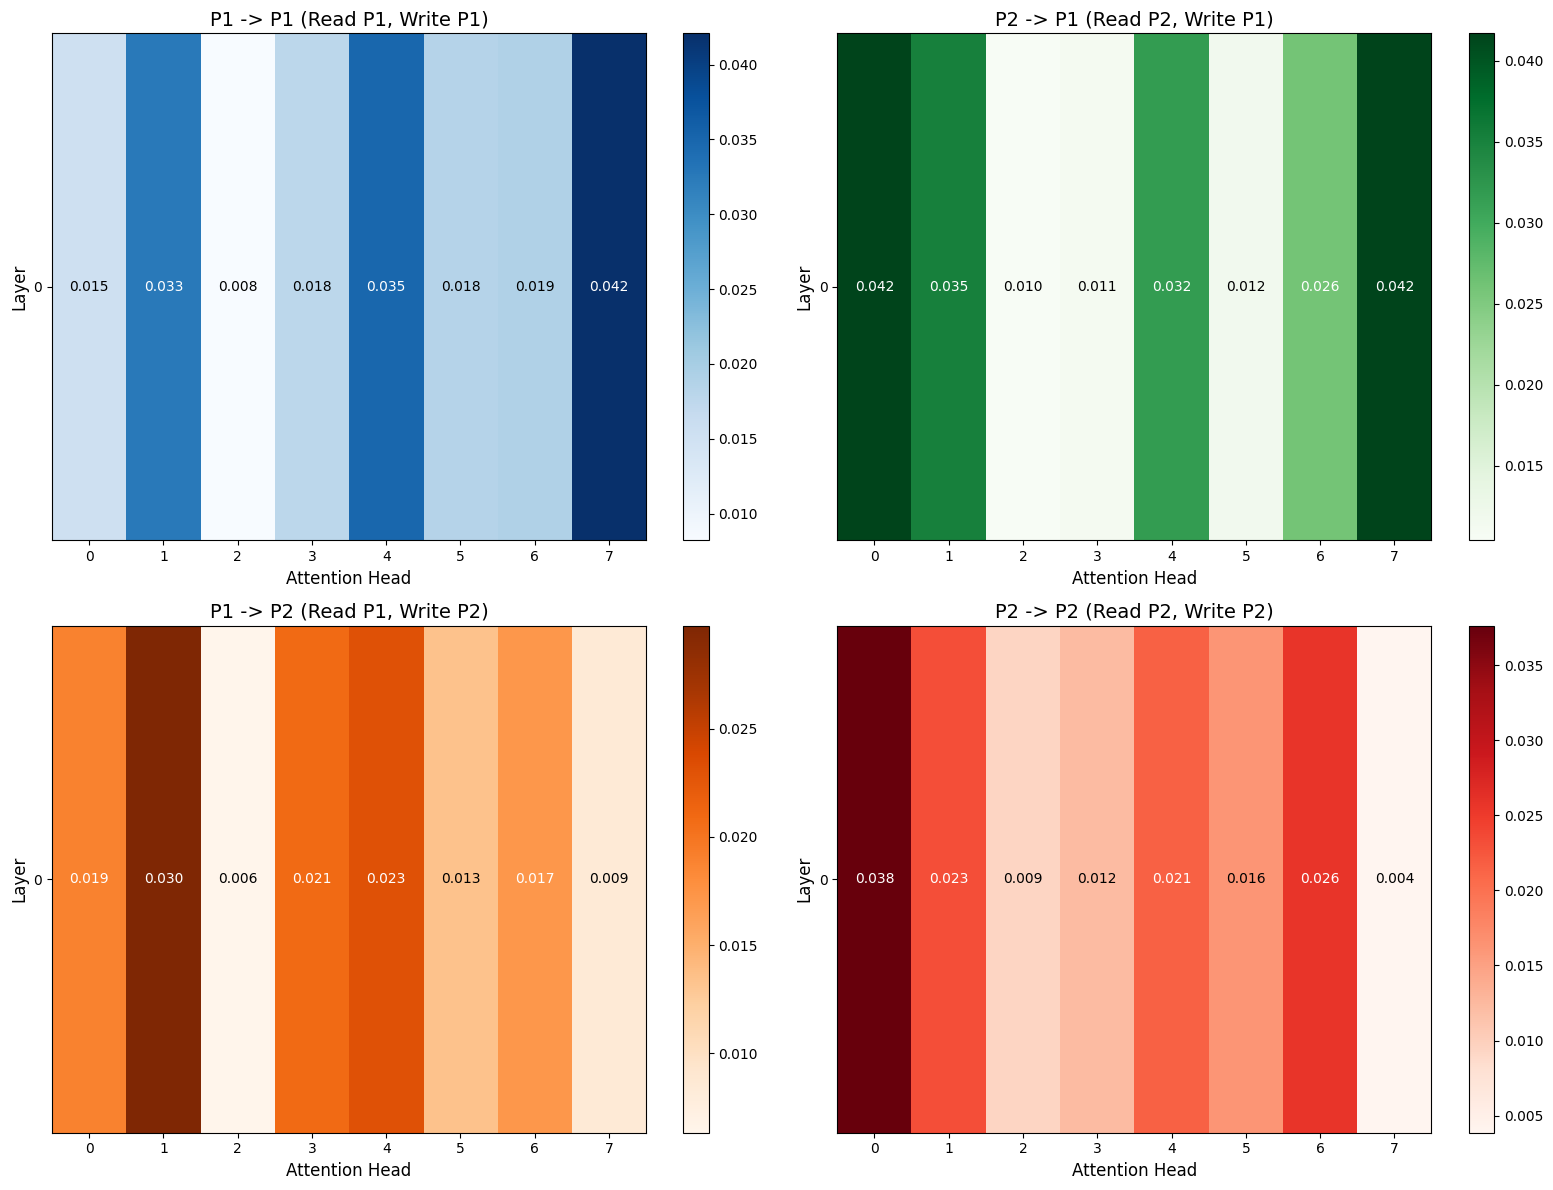

OV Subspace Analysis Complete. Plots saved to stage_p_0.9_25_mixed_ctx_100_l1_d_64_resume_4b_st_fixed\evaluation\ov_subspace_norms.png


In [23]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Extract model parameters
n_layers = model.cfg.n_layers
n_heads = model.cfg.n_heads
d_model = model.cfg.d_model
W_V = model.W_V  # (n_layers, n_heads, d_model, d_head)
W_O = model.W_O  # (n_layers, n_heads, d_head, d_model)
W_OV = W_V @ W_O # (n_layers, n_heads, d_model, d_model)

# Heatmaps for norms
norms_P1_P1 = np.zeros((n_layers, n_heads))
norms_P2_P1 = np.zeros((n_layers, n_heads))
norms_P1_P2 = np.zeros((n_layers, n_heads))
norms_P2_P2 = np.zeros((n_layers, n_heads))

probe_dir = Path(CHECKPOINT_DIR) / "probe_weights"

def get_orthonormal_basis(C):
    # C has shape (3, 64)
    # SVD: C = U @ S @ Vh, so Vh has shape (3, 64) and its rows are an orthonormal basis for the row space of C
    _, _, Vh = torch.linalg.svd(C, full_matrices=False)
    return Vh

for l in range(n_layers):
    # Determine the "read" layer (pre)
    if l == 0:
        c_pre_p1 = torch.load(probe_dir / "blocks.0.hook_resid_pre_p1_weights.pt", map_location='cpu', weights_only=True)
        c_pre_p2 = torch.load(probe_dir / "blocks.0.hook_resid_pre_p2_weights.pt", map_location='cpu', weights_only=True)
    else:
        c_pre_p1 = torch.load(probe_dir / f"blocks.{l-1}.hook_resid_post_p1_weights.pt", map_location='cpu', weights_only=True)
        c_pre_p2 = torch.load(probe_dir / f"blocks.{l-1}.hook_resid_post_p2_weights.pt", map_location='cpu', weights_only=True)
    
    # Determine the "write" layer (mid)
    c_mid_p1 = torch.load(probe_dir / f"blocks.{l}.hook_resid_mid_p1_weights.pt", map_location='cpu', weights_only=True)
    c_mid_p2 = torch.load(probe_dir / f"blocks.{l}.hook_resid_mid_p2_weights.pt", map_location='cpu', weights_only=True)
    
    # Extract scale-independent orthonormal bases for the subspaces
    vh_pre_p1 = get_orthonormal_basis(c_pre_p1)
    vh_pre_p2 = get_orthonormal_basis(c_pre_p2)
    vh_mid_p1 = get_orthonormal_basis(c_mid_p1)
    vh_mid_p2 = get_orthonormal_basis(c_mid_p2)
    
    for h in range(n_heads):
        # Compute norms
        w_ov = W_OV[l, h].cpu()
        
        # Normalize W_OV
        w_ov = w_ov / torch.norm(w_ov, p='fro')
        
        norms_P1_P1[l, h] = torch.norm(vh_pre_p1 @ w_ov @ vh_mid_p1.T, p='fro').item()
        norms_P2_P1[l, h] = torch.norm(vh_pre_p2 @ w_ov @ vh_mid_p1.T, p='fro').item()
        norms_P1_P2[l, h] = torch.norm(vh_pre_p1 @ w_ov @ vh_mid_p2.T, p='fro').item()
        norms_P2_P2[l, h] = torch.norm(vh_pre_p2 @ w_ov @ vh_mid_p2.T, p='fro').item()

# Create Evaluation Directory if it doesn't exist
eval_dir = Path(CHECKPOINT_DIR) / "evaluation"
eval_dir.mkdir(parents=True, exist_ok=True)

# Plotting Heatmaps
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
axs = axs.flatten()

heatmaps = [
    (norms_P1_P1, "P1 -> P1 (Read P1, Write P1)", 'Blues'),
    (norms_P2_P1, "P2 -> P1 (Read P2, Write P1)", 'Greens'),
    (norms_P1_P2, "P1 -> P2 (Read P1, Write P2)", 'Oranges'),
    (norms_P2_P2, "P2 -> P2 (Read P2, Write P2)", 'Reds')
]

for i, (data, title, cmap) in enumerate(heatmaps):
    im = axs[i].imshow(data, cmap=cmap, aspect='auto', origin='upper')
    fig.colorbar(im, ax=axs[i])
    # Add text annotations
    for y in range(data.shape[0]):
        for x in range(data.shape[1]):
            val = data[y, x]
            color = 'white' if val > data.max() / 2 else 'black'
            axs[i].text(x, y, f"{val:.3f}", ha="center", va="center", color=color)
    
    axs[i].set_title(title, fontsize=14)
    axs[i].set_xlabel("Attention Head", fontsize=12)
    axs[i].set_ylabel("Layer", fontsize=12)
    axs[i].set_xticks(np.arange(n_heads))
    axs[i].set_yticks(np.arange(n_layers))

plt.tight_layout()
plt.savefig(eval_dir / "ov_subspace_norms.png", dpi=150)
plt.show()

print("OV Subspace Analysis Complete. Plots saved to", eval_dir / "ov_subspace_norms.png")

In [24]:
vh_pre_p1 @ vh_mid_p1.T

tensor([[ 9.8312e-01, -1.2394e-01, -4.2812e-04],
        [ 1.2913e-01,  9.8710e-01,  4.8625e-03],
        [-2.6115e-02, -3.9679e-03,  3.2810e-01]])